In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import scipy.stats as st
# from uncertainties import ufloat
# import uncertainties
# from uncertainties.umath import *
pd.set_option('future.no_silent_downcasting', True)

In [3]:
figure_folder = Path('../../Figures/interactions')
figure_folder.mkdir(exist_ok=True)

In [4]:
folder = Path('../../data/3_interactions/')

spent_mannose_fn = folder / 'cfus_spent_mannose.csv'
fresh_mannose_fn = folder / 'cfus_fresh_mannose.csv'
spent_malate_fn = folder / 'cfus_spent_malate.csv'
fresh_malate_fn = folder / 'cfus_fresh_malate.csv'

files = [spent_mannose_fn, fresh_mannose_fn, spent_malate_fn, fresh_malate_fn]
dfs = []
for fn in files:
    df = pd.read_csv(fn, index_col=0)
    if 'spent' in str(fn):
        df['spent'] = True
    else:
        df['spent'] = False
    dfs.append(df)
df = pd.concat(dfs)

In [5]:
df.Medium.unique()

array([nan, 'Ml_mannose', 'Ct_isoleucine', 'Oa_mannose', 'No_CS',
       'At_mannose', 'M9_mannose', 'M9_mannose+thiamine',
       'M9_mannose+thiamine+biotin+cysteine+proline', 'M9_isoleucine',
       'M9_isoleucine+thiamine+biotin+cysteine+proline',
       'M9_isoleucine+thiamine', 'At-malate', 'Ct-malate', 'Ml-malate',
       'Oa-malate', 'No-CS', 'M9-malate', 'M9-malate+thiamine',
       'M9-malate+thiamine+biotin+cysteine+proline'], dtype=object)

In [6]:
# Remove nan rows
df.dropna(subset=['CFUs/mL', 'Medium'], inplace=True)
# df.loc[(df.Medium.isna())].iloc[40:80]

In [7]:
# Remove inoculum wells
df = df.loc[df['Well'] != 'Inoculum']

# Remove nan rows
df = df.dropna(subset=['CFUs/mL'])

df.replace(['No_CS', 'No-CS'], 'No CS', inplace=True)
df['Medium'] = df['Medium'].str.replace('-', '_')

df['Base carbon source'] = [x.split('+')[0].capitalize() if isinstance(x, str) else 'No CS'  for x in  df.Medium.str.replace('_','-').str.split('-').str[1]]

df.reset_index(drop=True, inplace=True)
df.head()

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,Base carbon source
0,B10,2,200000000.0,At,At+Ct,Ml_mannose,0.001,True,Mannose
1,C11,2,300000000.0,At,At+Oa,Ml_mannose,0.001,True,Mannose
2,D1,2,520000000.0,At,At,Ct_isoleucine,0.001,True,Isoleucine
3,D4,2,260000000.0,At,At+Ml,Ct_isoleucine,0.001,True,Isoleucine
4,D5,2,300000000.0,At,At+Oa,Ct_isoleucine,0.001,True,Isoleucine


In [8]:
df['Base carbon source'].unique()

array(['Mannose', 'Isoleucine', 'No CS', 'Malate'], dtype=object)

In [9]:
print(df.Medium.unique())

df['Base carbon source'].unique()

for i, row in df.iterrows():
    if row['Medium'].split('_')[0] in ['At', 'Ct', 'Ml', 'Oa']:
        short_name = row['Medium'].split('_')[0]
        bg = row['Medium'].split('_')[0]
    elif row['Medium']=='No CS':
        short_name = 'No CS'
        bg = 'No CS'
    else:
        short_name = 'Fresh'
        bg = 'Fresh'
        if row['Medium'].split('+')[-1]=='thiamine':
            short_name += ' + T'
        elif row['Medium'].split('+')[-1]=='proline':
            short_name += ' + Vit. & AA'
    
    if '+' in row['Inoculated species']:
        partner = row['Inoculated species'].replace(row['Species'], '').replace('+', '')
        short_name += f' ({partner})'
    else:
        partner = 'No partner'
    
    if bg == 'Fresh':
        if '+' in row['Inoculated species']:
            bg += ' (coculture)'
        else:
            bg += ' (monoculture)'

    df.at[i, 'Short name'] = short_name
    df.at[i, 'Background'] = bg
    df.at[i, 'Partner'] = partner
    


['Ml_mannose' 'Ct_isoleucine' 'Oa_mannose' 'No CS' 'At_mannose'
 'M9_mannose' 'M9_mannose+thiamine'
 'M9_mannose+thiamine+biotin+cysteine+proline' 'M9_isoleucine'
 'M9_isoleucine+thiamine+biotin+cysteine+proline' 'M9_isoleucine+thiamine'
 'At_malate' 'Ct_malate' 'Ml_malate' 'Oa_malate' 'M9_malate'
 'M9_malate+thiamine' 'M9_malate+thiamine+biotin+cysteine+proline']


In [10]:
df.loc[(df.Medium == 'M9_isoleucine')&(df.Plate==3), 'Short name'] = 'Fresh'
df.loc[(df.Medium == 'No CS')&(df.Plate==3), 'Short name'] = 'No CS 2'
df.loc[(df.Medium == 'Ct_isoleucine')&(df.Plate==3), 'Short name'] =df.loc[(df.Medium == 'Ct_isoleucine')&(df.Plate==3), 'Short name'] + ' 2'


# Plot

In [11]:
df['Base carbon source'].unique()

array(['Mannose', 'Isoleucine', 'No CS', 'Malate'], dtype=object)

# At

['Ml (Ct)' 'Ml (Oa)' 'Oa (Ml)' 'No CS' 'At' 'Ml' 'Oa' 'Oa (Ct)'
 'Fresh (Ct)' 'Fresh (Ml)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 16
16


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/1418475617.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


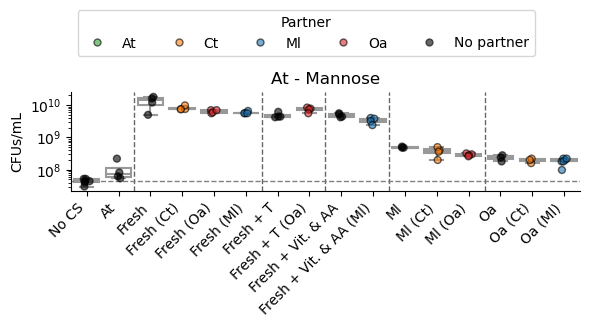

In [12]:
s = 'At'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'At',
         'Fresh', 
          'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
        #  'Ct', 'Ct (Ml)', 'Ct (Oa)',

         'Ml', 'Ml (Ct)', 'Ml (Oa)',
         'Oa', 'Oa (Ct)', 'Oa (Ml)',

         ]
partner_palette = {
    'At': 'C2',
    'Ct': 'C1',
    'Oa': 'C3',
    'Ml': 'C0',
    'No partner': 'k',
}
fig, ax = plt.subplots(figsize=(6, 4))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 7.5, 9.5, 12.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
# ax.text(9.7, df.loc[sidx, 'CFUs/mL'].max(), 'Isoleucine', fontsize=12, ha='left', va='center', rotation=0)
sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.3)  , loc='lower left', fontsize=10)

ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

4


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/4273028588.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


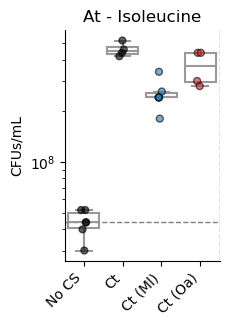

In [13]:
#Isoleucine

s = 'At'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 'Ct (Ml)', 'Ct (Oa)',
        #  'No CS 2',
        #           'Fresh',
        #           'Ct 2' 
         
         ]
fig, ax = plt.subplots(figsize=(2, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
ax.axvline(x=3.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.6,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

['At' 'Ct' 'Ml' 'Oa' 'No CS' 'Ct (Ml)' 'Ml (Ct)' 'Oa (Ct)' 'Ct (Oa)'
 'Ml (Oa)' 'Oa (Ml)' 'Fresh (Ct)' 'Fresh (Ml)' 'Fresh (Oa)'
 'Fresh + T (Oa)' 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T'
 'Fresh + Vit. & AA'] 19
19


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/4150745095.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


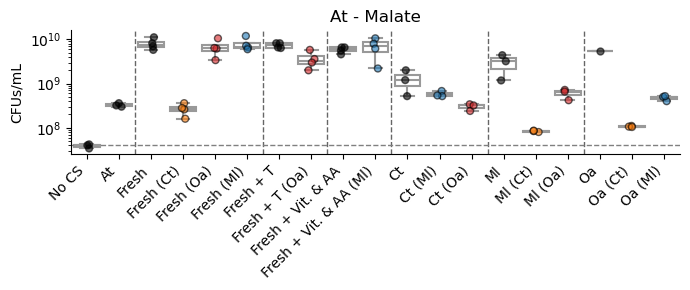

In [14]:
s = 'At'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'At',
         'Fresh', 
         'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 'Ct (Ml)', 'Ct (Oa)',

         'Ml', 'Ml (Ct)', 'Ml (Oa)',
         'Oa', 'Oa (Ct)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 7.5, 9.5, 12.5, 15.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
# ax.text(9.7, df.loc[sidx, 'CFUs/mL'].max(), 'Isoleucine', fontsize=12, ha='left', va='center', rotation=0)
# sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.3)  , loc='lower left', fontsize=10)

ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


# Ct

In [15]:
# df.loc[(df['Species']=='Ct')&(df['Base carbon source']=='Mannose')&(df['Short name']=='Fresh + T'), 'CFUs/mL'] *= 10

['At' 'At (Ml)' 'At (Oa)' 'Ml' 'Ml (At)' 'Oa' 'Oa (Ml)' 'No CS' 'Ml (Oa)'
 'Oa (At)' 'Fresh (At)' 'Fresh (Ml)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 18
18


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/2336812910.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


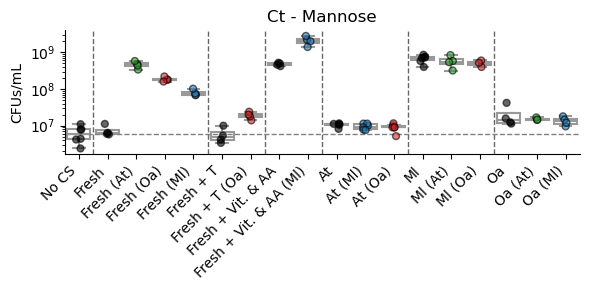

In [16]:
s = 'Ct'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Fresh', 
          'Fresh (At)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ml)', 'At (Oa)',

         'Ml', 'Ml (At)', 'Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(6, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [0.5, 4.5, 6.5, 8.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['No CS' 'Ct' 'Ct 2' 'Fresh' 'No CS 2'] 5


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/276072428.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


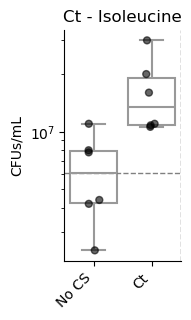

In [17]:
#Isoleucine

s = 'Ct'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2,3]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 
        #  'No CS 2',
        #           'Fresh',
        #           'Ct 2' 
         
         ]

fig, ax = plt.subplots(figsize=(1.5, 3))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
ax.axvline(x=1.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.5,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

['At' 'Ct' 'Ml' 'Oa' 'No CS' 'At (Ml)' 'Ml (At)' 'Oa (At)' 'At (Oa)'
 'Ml (Oa)' 'Oa (Ml)' 'Fresh (At)' 'Fresh (Ml)' 'Fresh (Oa)'
 'Fresh + T (Oa)' 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T'
 'Fresh + Vit. & AA'] 19
19


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/56239609.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


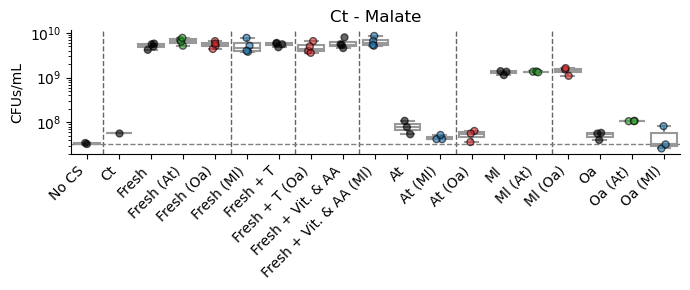

In [18]:
s = 'Ct'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Ct',
         'Fresh', 
          'Fresh (At)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ml)', 'At (Oa)',

         'Ml', 'Ml (At)', 'Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [0.5, 4.5, 6.5, 8.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
# ax.text(9.7, df.loc[sidx, 'CFUs/mL'].max(), 'Isoleucine', fontsize=12, ha='left', va='center', rotation=0)
# sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.3)  , loc='lower left', fontsize=10)

ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


# Ml

['At' 'At (Ct)' 'At (Oa)' 'Oa (At)' 'Oa (Ct)' 'No CS' 'Ml' 'Oa'
 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (At)' 'Fresh + Vit. & AA (Ct)'
 'Fresh + Vit. & AA (Oa)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 18
18


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/1340682351.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


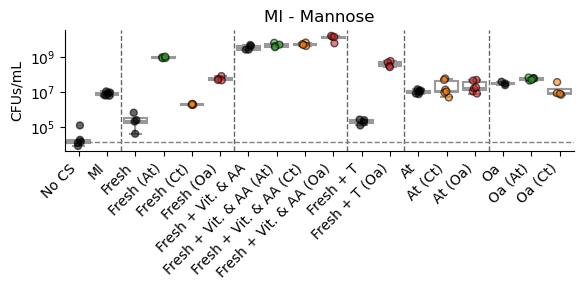

In [19]:
s = 'Ml'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Ml',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
            'Fresh + Vit. & AA (Oa)',
         
         'Fresh + T', 'Fresh + T (Oa)',
         'At', 'At (Ct)', 'At (Oa)',

        #  'Ct', 'Ct (At)', 'Ct (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)',

         ]

fig, ax = plt.subplots(figsize=(6, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['Ct' 'Ct (At)' 'Ct (Oa)' 'No CS'] 4


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/495419047.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


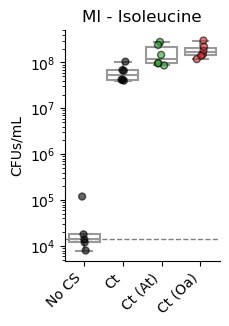

In [20]:
#Isoleucine

s = 'Ml'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
         #   'Fresh + Vit. & AA',
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 
         'Ct (At)',
         'Ct (Oa)',


         # 'No CS 2',
                  # 'Fresh',
                  # 'Ct 2' 
         
         ]

fig, ax = plt.subplots(figsize=(2, 3))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
# ax.axvline(x=4.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.7,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['At' 'Ct' 'Ml' 'Oa' 'No CS' 'At (Ct)' 'Ct (At)' 'Oa (At)' 'At (Oa)'
 'Ct (Oa)' 'Oa (Ct)' 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Oa)'
 'Fresh + T (Oa)' 'Fresh + Vit. & AA (At)' 'Fresh + Vit. & AA (Ct)'
 'Fresh + Vit. & AA (Oa)' 'Fresh + T' 'Fresh + Vit. & AA' 'Fresh'] 21
21


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/4137059761.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


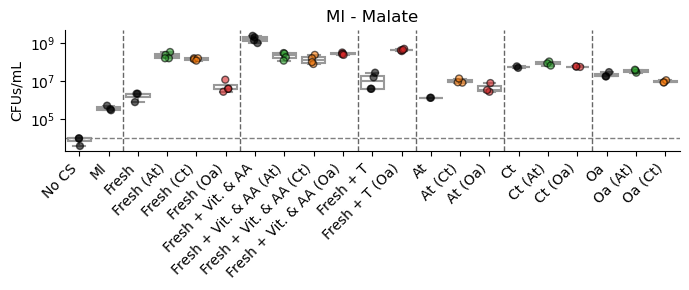

In [21]:
s = 'Ml'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Ml',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
            'Fresh + Vit. & AA (Oa)',
         
         'Fresh + T', 'Fresh + T (Oa)',
         'At', 'At (Ct)', 'At (Oa)',

         'Ct', 'Ct (At)', 'Ct (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5, 17.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


# Oa

['At' 'At (Ct)' 'At (Ml)' 'Ml' 'Ml (At)' 'No CS' 'Oa' 'Ml (Ct)'
 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Ml)' 'Fresh + T (At)' 'Fresh + T (Ct)'
 'Fresh + T (Ml)' 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T'
 'Fresh + Vit. & AA'] 18
18


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/1360809093.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


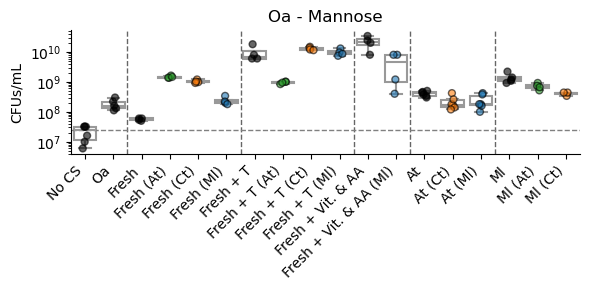

In [22]:
s = 'Oa'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Oa',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)',
        'Fresh + T (Ml)',
        'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ct)', 'At (Ml)',

        #  'Ct', 'Ct (At)', 'Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)',
        



         ]

fig, ax = plt.subplots(figsize=(6, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['Ct' 'Ct (At)' 'Ct (Ml)' 'No CS'] 4


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/578865198.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


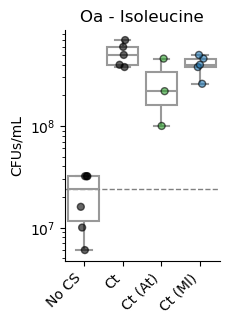

In [23]:
#Isoleucine

s = 'Oa'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
         #   'Fresh + T',
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 
         'Ct (At)',
         'Ct (Ml)',


         # 'No CS 2',
                  # 'Fresh',
                  # 'Ct 2' 
         
         ]

fig, ax = plt.subplots(figsize=(2, 3))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
# ax.axvline(x=4.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.7,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['At' 'Ct' 'Ml' 'Oa' 'No CS' 'At (Ct)' 'Ct (At)' 'Ml (At)' 'At (Ml)'
 'Ct (Ml)' 'Ml (Ct)' 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Ml)'
 'Fresh + T (At)' 'Fresh + T (Ct)' 'Fresh + T (Ml)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 21
21


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/3678094694.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


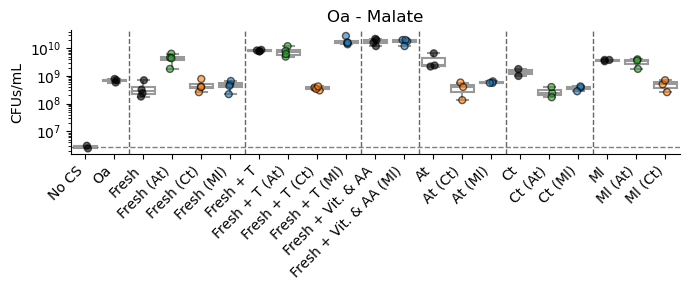

In [24]:
s = 'Oa'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Oa',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)',
        'Fresh + T (Ml)',
        'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ct)', 'At (Ml)',

         'Ct', 'Ct (At)', 'Ct (Ml)',
         'Ml', 'Ml (At)', 'Ml (Ct)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5, 17.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

## All species together - malate

32


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/3539817016.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees


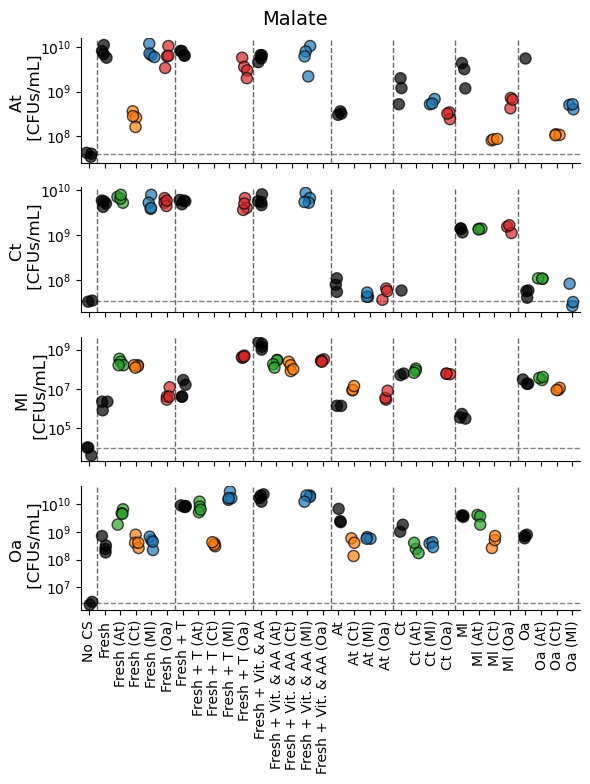

In [25]:
s = 'Oa'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
# print(sn, len(sn))
order = ['No CS', 
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
         'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
         'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', 'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', 'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(4, 1, figsize=(6,8), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Partner',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('')
    if i == 3:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
        ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}.pdf', bbox_inches='tight')

## Mannose

28


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_56873/2614116191.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees


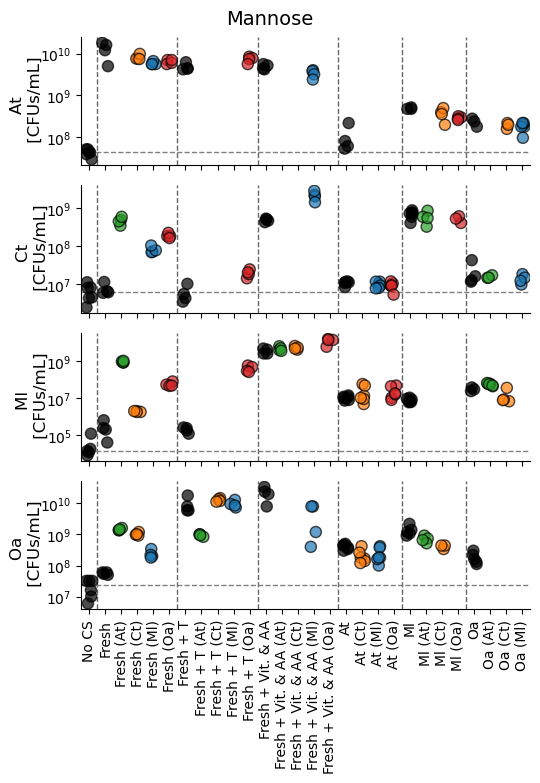

In [26]:
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
# print(sn, len(sn))
order = ['No CS', 
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
         'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
         'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', 'At (Ct)', 'At (Ml)','At (Oa)',
        #  'Ct', 'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(4, 1, figsize=(5.5,8), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    legend = False
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Partner',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('')
    if i == 3:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5]:
        ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}.pdf', bbox_inches='tight')

# All species spent only


5


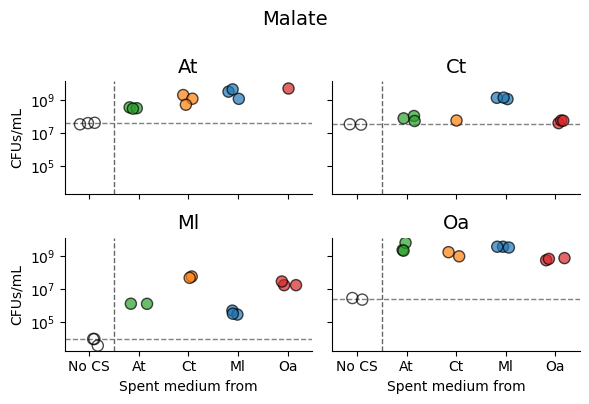

In [44]:
s = 'Oa'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
# print(sn, len(sn))
order = ['No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', #'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=True)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Short name',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    # ax.set_ylabel(f'[CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    ax.set_title(f'{s}', fontsize=14)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from')
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.png', bbox_inches='tight', dpi=300)

4


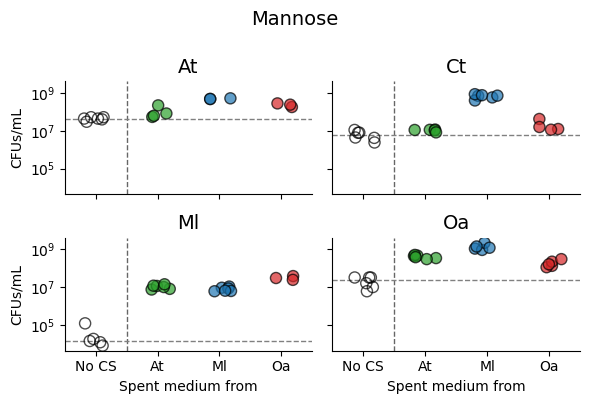

In [45]:
s = 'Oa'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
# print(sn, len(sn))
order = ['No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', #'At (Ct)', 'At (Ml)','At (Oa)',
        #  'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=True)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Short name',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    # ax.set_ylabel(f'[CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    ax.set_title(f'{s}', fontsize=14)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from')
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.png', bbox_inches='tight', dpi=300)

# Save data


In [104]:
df.to_csv(folder/'all_interactions_cfus.csv')

## Read OD and fluorescent data as well at least of fresh!

# Plot data

## Spent mannose 2

In [105]:
cfu_df = cfu_df_dict['spent_mannose2']
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

NameError: name 'cfu_df_dict' is not defined

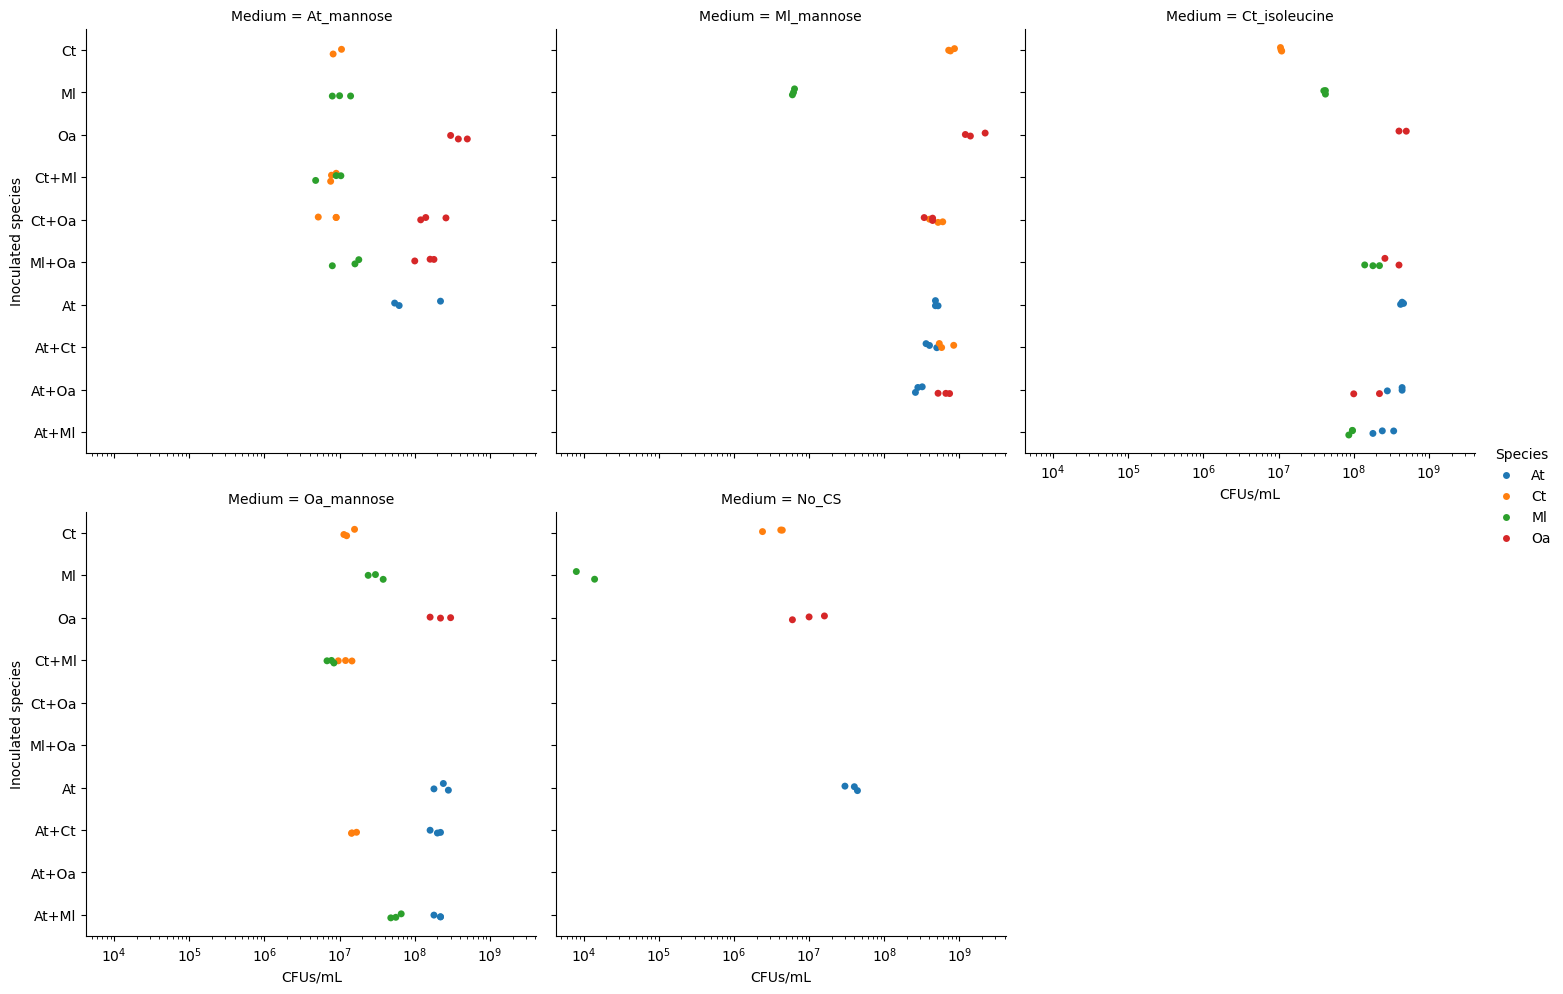

In [ ]:
cfu_df = cfu_df_dict['spent_mannose3']
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

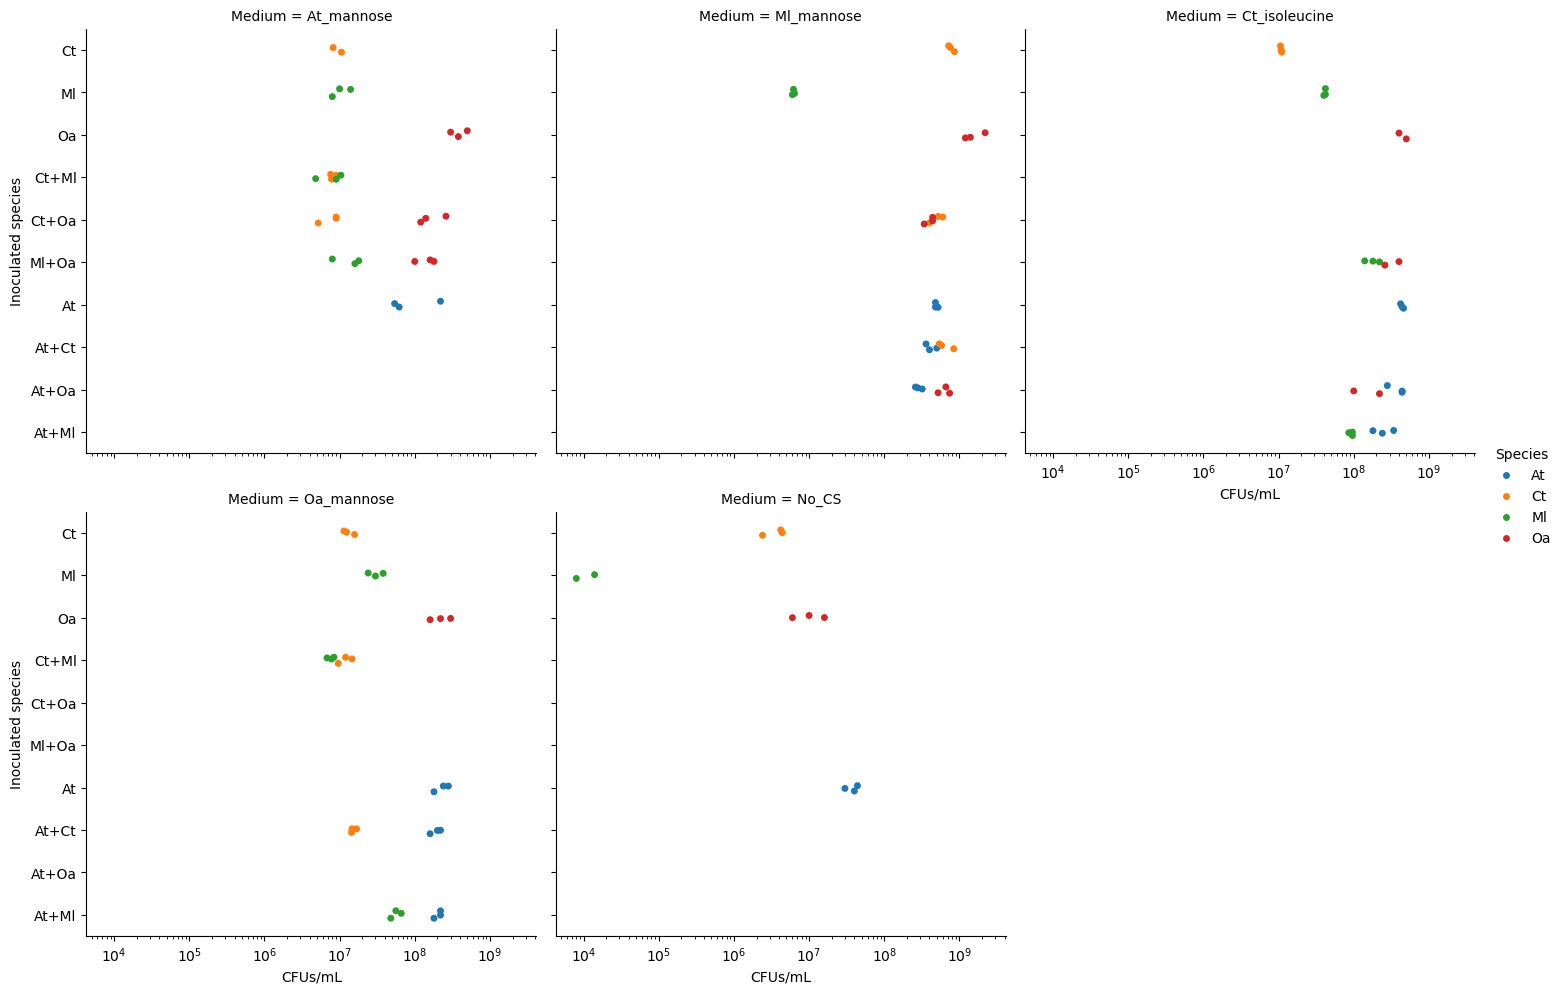

In [ ]:
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

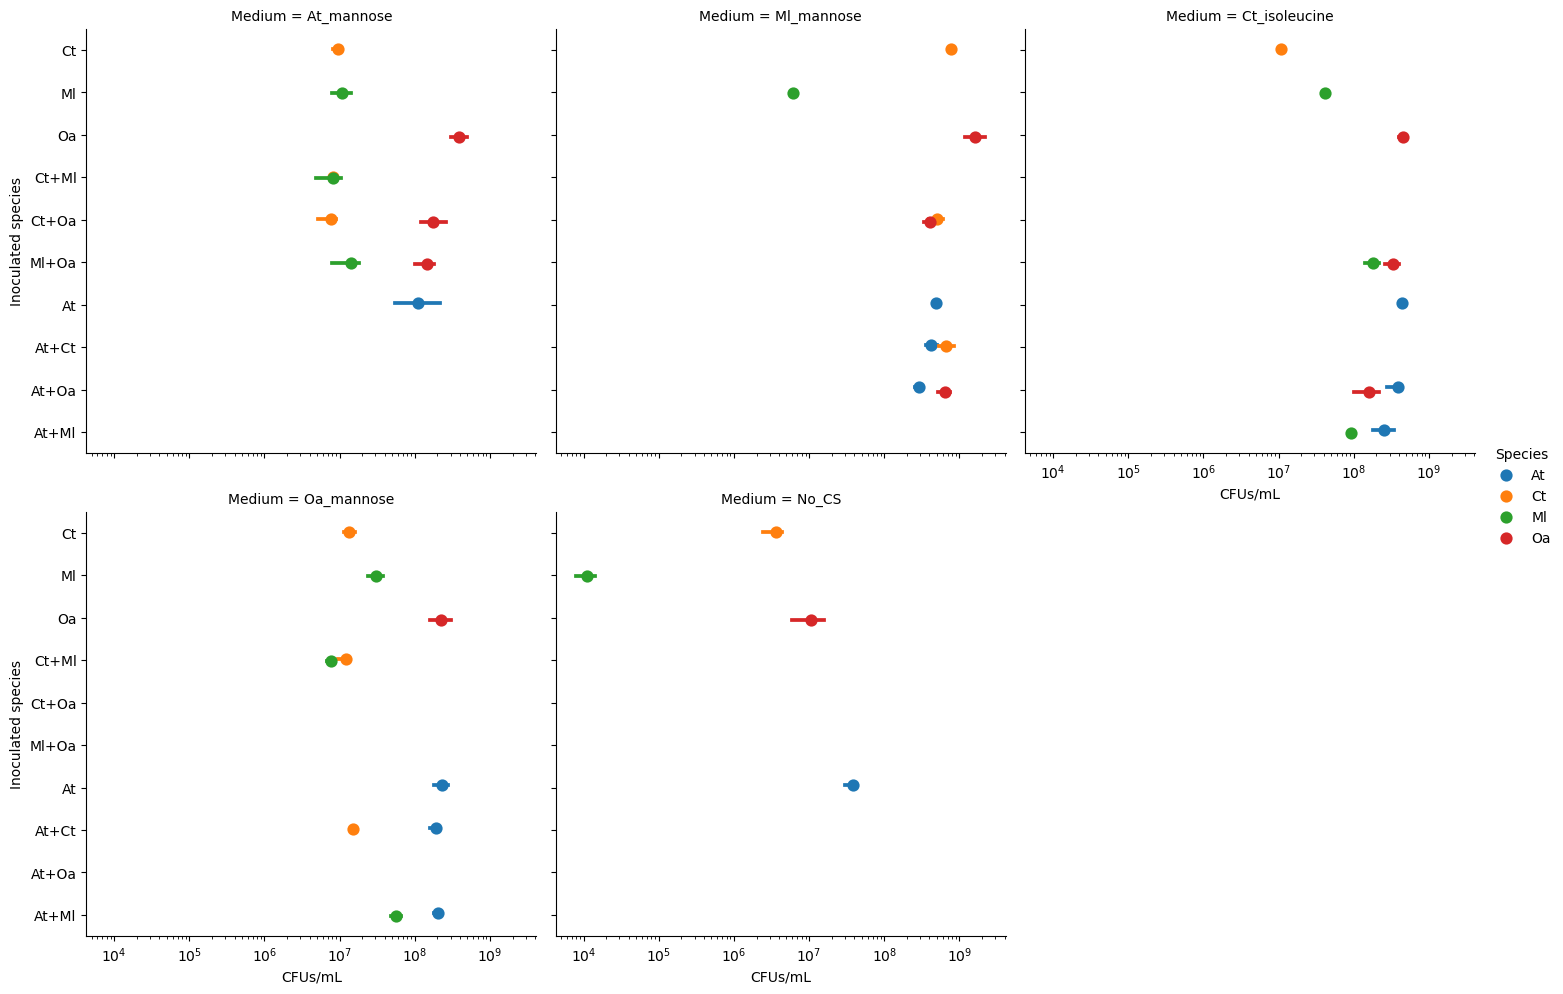

In [ ]:
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'point', dodge=True, markers="o", linestyle = 'None')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

# Quantify interactions

In [ ]:
# Join spent mannose data
spent_mannose_cfu = pd.concat([cfu_df_dict['spent_mannose2'], cfu_df_dict['spent_mannose3']])
spent_mannose_cfu.reset_index(inplace=True, drop = True)

In [ ]:
spent_mannose_cfu.to_csv('cfus_spent_mannose.csv')

## Spent medium

In [ ]:
spent_mannose_cfu['Inoculated species'].astype('str')

0      nan
1      nan
2      nan
3      nan
4      nan
      ... 
715     Ml
716     Ml
717     Oa
718     Oa
719     Oa
Name: Inoculated species, Length: 720, dtype: object

In [ ]:
spent_mannose_cfu['Is coculture'] = spent_mannose_cfu['Inoculated species'].str.contains(r'\+')
four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in spent_mannose_cfu.Medium.unique():
    if medium == 'No_CS':
        continue
    dfm = spent_mannose_cfu.loc[spent_mannose_cfu.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
spent_mannose_isoleucine_interactions = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])

In [ ]:
spent_isoleucine_interactions = spent_mannose_isoleucine_interactions.loc[spent_mannose_isoleucine_interactions.Medium.str.contains('isoleucine')]
spent_mannose_interactions = spent_mannose_isoleucine_interactions.loc[spent_mannose_isoleucine_interactions.Medium.str.contains('mannose')]

# Fresh mannose

In [ ]:
fresh_mannose_cfu = cfu_df_dict['fresh_mannose']
fresh_mannose_cfu['Is coculture'] = fresh_mannose_cfu['Inoculated species'].str.contains(r'\+')
four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in fresh_mannose_cfu.Medium.unique():
    if medium == 'No_CS':
        continue
    dfm = fresh_mannose_cfu.loc[fresh_mannose_cfu.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        # lrr_s1 = np.log10(s1_growth_in_co.mean()/s1_growth_in_mono.mean())
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        
        # the uncertainty package estimates matches with how to in https://en.wikipedia.org/wiki/Propagation_of_uncertainty
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
fresh_mannose_interactions = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])

In [ ]:
spent_mannose_interactions

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue
0,Ct,Ml,At_mannose,-0.042771,0.094802,0.318843
1,Ml,Ct,At_mannose,0.360580,0.428275,0.181713
2,Ct,Oa,At_mannose,-0.067773,0.116755,0.201653
3,Oa,Ct,At_mannose,-0.274574,0.240609,0.006504
4,Ml,Oa,At_mannose,0.363594,0.329930,0.085762
5,Oa,Ml,At_mannose,-0.231527,0.253162,0.022293
6,At,Ct,Ml_mannose,-0.130848,0.149839,0.146230
7,Ct,At,Ml_mannose,-0.070200,0.192876,0.419410
8,At,Oa,Ml_mannose,-0.230742,0.043686,0.000121
9,Oa,At,Ml_mannose,-0.282281,0.189848,0.043636


In [ ]:
fresh_mannose_interactions

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue
0,At,Ct,M9_mannose,-0.197025,0.204718,1.629299e-01
1,Ct,At,M9_mannose,1.796470,0.178920,9.824423e-05
2,At,Ml,M9_mannose,-0.338354,0.198920,5.356951e-02
3,Ml,At,M9_mannose,3.518984,0.398043,1.043443e-06
4,At,Oa,M9_mannose,-0.299330,0.201307,7.041765e-02
5,Oa,At,M9_mannose,1.414675,0.051844,3.746039e-07
6,Ct,Ml,M9_mannose,1.031340,0.175135,1.050370e-04
7,Ml,Ct,M9_mannose,0.831596,0.396524,2.506001e-05
8,Ct,Oa,M9_mannose,1.400884,0.163425,8.129531e-06
9,Oa,Ct,M9_mannose,1.264649,0.063461,3.589759e-06


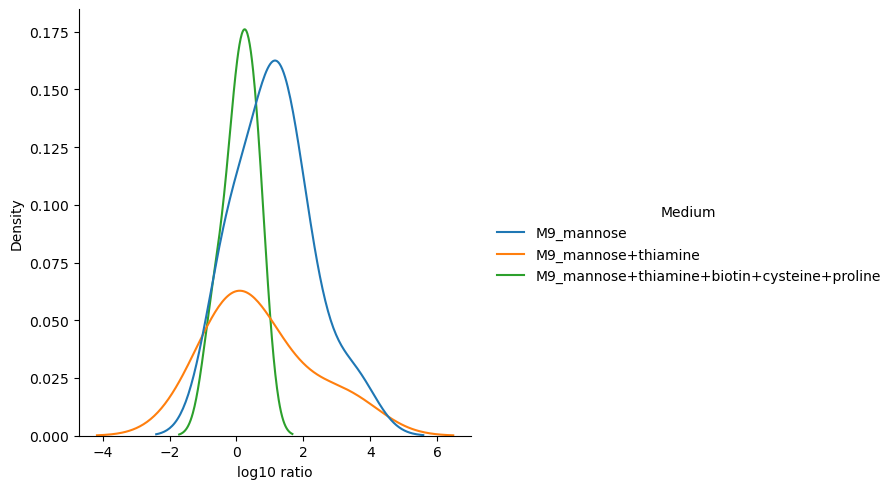

In [ ]:
ax = sns.displot(data = fresh_mannose_interactions, x = 'log10 ratio', hue = 'Medium', kind = 'kde')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

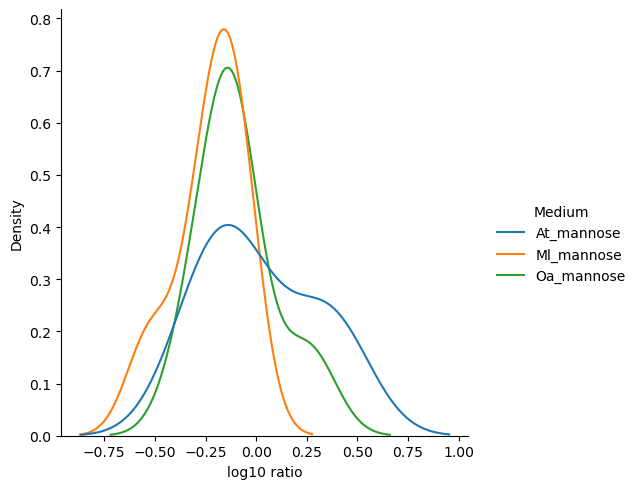

In [ ]:
ax = sns.displot(data = spent_mannose_interactions, x = 'log10 ratio', hue = 'Medium', kind = 'kde')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [ ]:
all_interactions = pd.concat([fresh_mannose_interactions, spent_mannose_interactions]).reset_index()

In [ ]:
all_interactions['log10 pval'] = np.log10(all_interactions['T-test pvalue'])

<Axes: xlabel='log10 ratio', ylabel='Medium'>

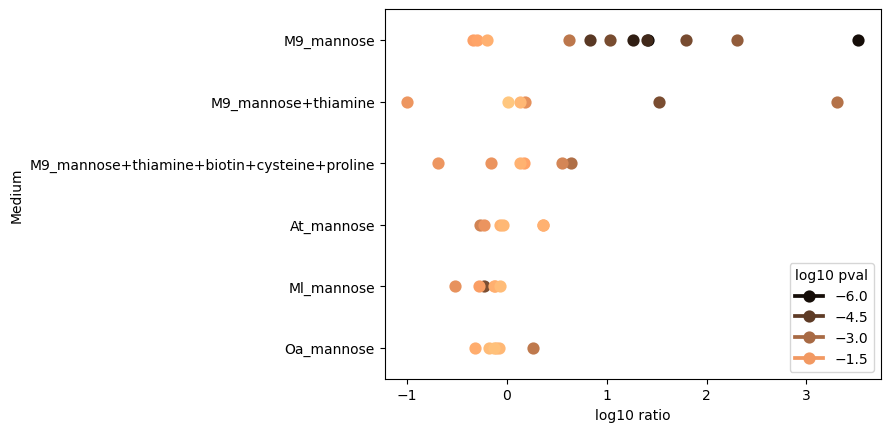

In [ ]:
sns.pointplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', hue = 'log10 pval', palette='copper')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_77193/3074553416.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


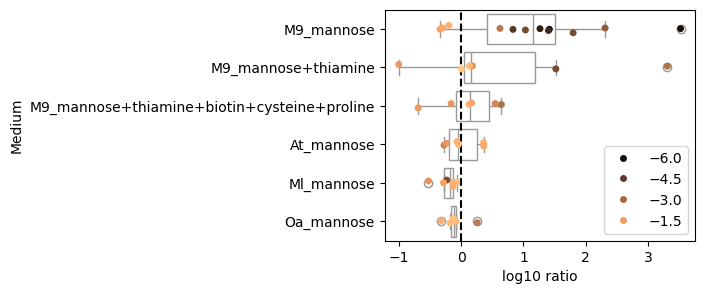

In [ ]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', hue = 'log10 pval', palette='copper', ax=ax)
sns.boxplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', color = 'w')
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
plt.savefig('Interactions mannose.pdf')

## Heatmaps

In [ ]:
all_interactions['Significance annot'] = ''
for i, row in all_interactions.iterrows():
    if 0.01 < row['T-test pvalue'] < 0.05:
        annot = '*'
    elif 0.001 < row['T-test pvalue'] < 0.01:
        annot = '**'
    elif row['T-test pvalue'] < 0.001:
        annot = '***'
    else:
        annot = ''
    all_interactions.at[i, 'Significance annot'] = annot
    

In [ ]:
all_interactions

,index,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,log10 pval,Significance annot
0,0,At,Ct,M9_mannose,-0.197025,0.204718,1.629299e-01,-0.787999,
1,1,Ct,At,M9_mannose,1.796470,0.178920,9.824423e-05,-4.007693,***
2,2,At,Ml,M9_mannose,-0.338354,0.198920,5.356951e-02,-1.271082,
3,3,Ml,At,M9_mannose,3.518984,0.398043,1.043443e-06,-5.981531,***
4,4,At,Oa,M9_mannose,-0.299330,0.201307,7.041765e-02,-1.152318,
5,5,Oa,At,M9_mannose,1.414675,0.051844,3.746039e-07,-6.426428,***
6,6,Ct,Ml,M9_mannose,1.031340,0.175135,1.050370e-04,-3.978658,***
7,7,Ml,Ct,M9_mannose,0.831596,0.396524,2.506001e-05,-4.601019,***
8,8,Ct,Oa,M9_mannose,1.400884,0.163425,8.129531e-06,-5.089934,***
9,9,Oa,Ct,M9_mannose,1.264649,0.063461,3.589759e-06,-5.444935,***


M9_mannose
M9_mannose+thiamine
M9_mannose+thiamine+biotin+cysteine+proline
At_mannose
Ml_mannose
Oa_mannose


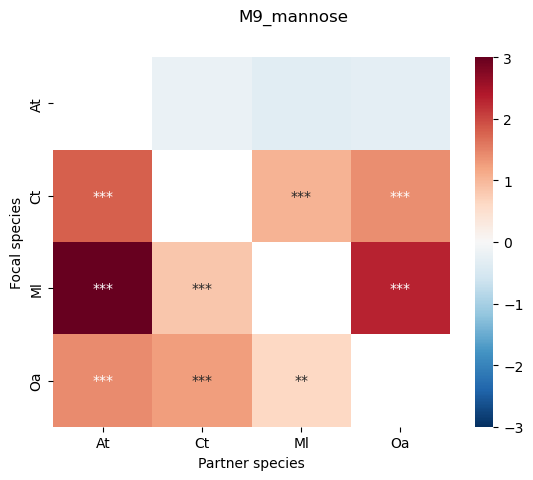

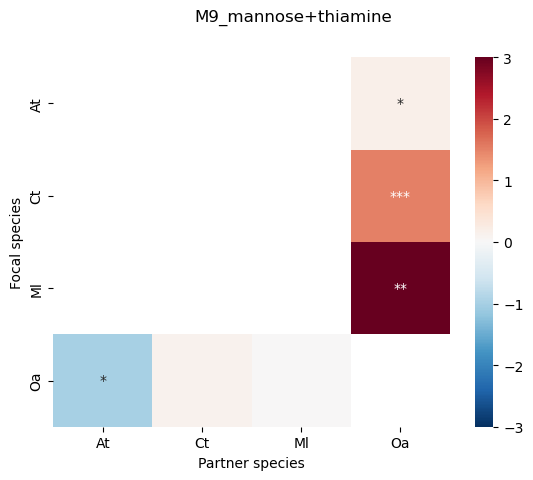

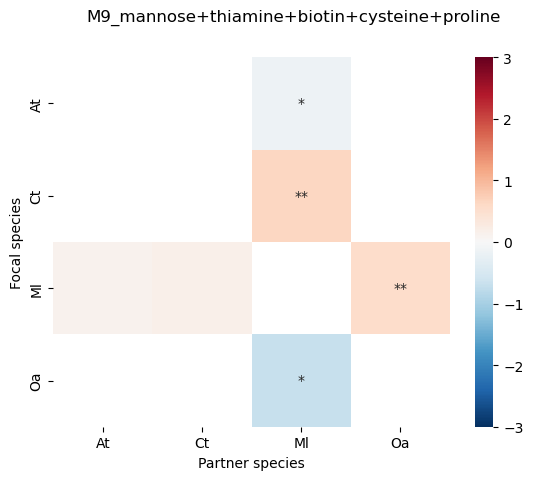

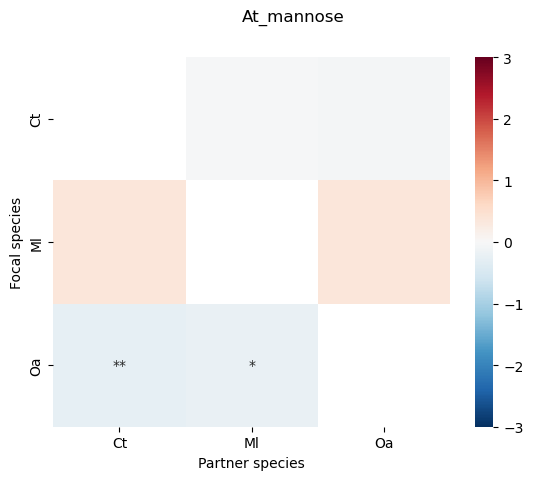

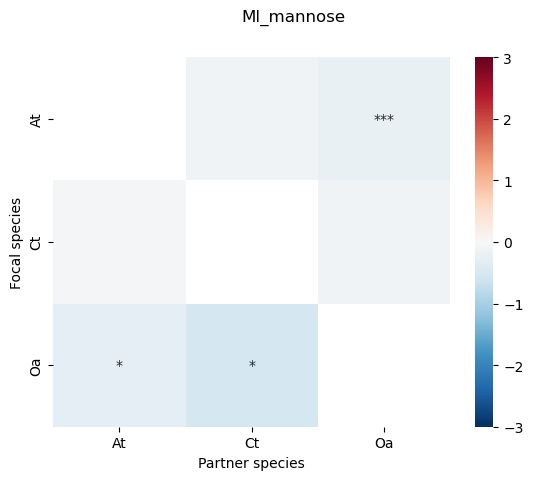

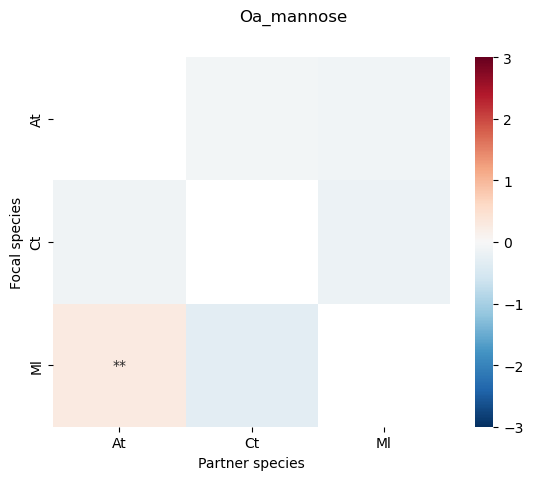

In [ ]:
for medium in all_interactions.Medium.unique():
    print(medium)
    dfm = all_interactions.loc[all_interactions.Medium==medium]
    dfmp = dfm.pivot(columns = 'Partner species', index = 'Focal species')
    fig, ax = plt.subplots(1)
    fig.suptitle(medium)
    sns.heatmap(dfmp['log10 ratio'], cmap = 'RdBu_r', ax = ax, vmin = -3, vmax = 3, annot = dfmp['Significance annot'], fmt = '')